Configurando entorno y cargando recursos...

🧠 Congelando base y calibrando modelo con el 40.0% de la señal (Fine-Tuning)...
⏳ Iniciando entrenamiento de calibración...
Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0118 - val_loss: 0.0095
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0079 - val_loss: 0.0069
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0068 - val_loss: 0.0062
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 0.0064 - val_loss: 0.0053
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 0.0061 - val_loss: 0.0048
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0058 - val_loss: 0.0047
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0057 - val_loss: 0.0043
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 9/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 0.0054 - val_loss: 0.0042
Epoch 10/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - lo

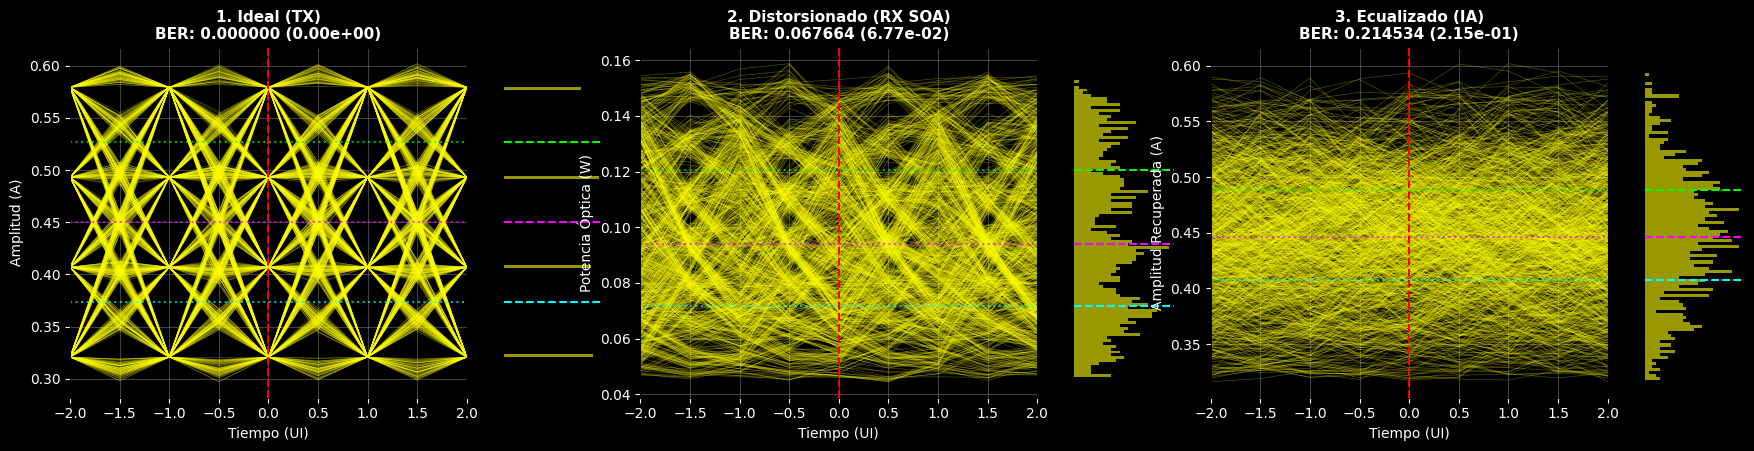


📊 RESULTADOS DE LA ECUALIZACIÓN Y FACTOR Q
❌ Sin Ecualizador (S/EQ) -> BER: 0.067664 | Q: 1.49 | Q[dB]: 3.48 dB
✅ Con Ecualizador (C/EQ) -> BER: 0.214534 | Q: 0.79 | Q[dB]: -2.04 dB



In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import bessel, filtfilt
from scipy.special import erfcinv
import json
import os
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras import layers

# --- 1. CONFIGURACIÓN ---
TEST_FILE = 'datasets' # <--- PON LA RUTA DE TU PARQUET AQUÍ
MODEL_PATH = 'teacher_soa_resnet.keras' 
SCALERS_PATH = 'scalers.json'

WINDOW_SIZE = 128
UI_SAMPLES = 2  
NUM_TRACES = 1000 
FEATURES = ['Output_P2', 'Bit_Rate', 'Beta_RC', 'Rango_Corr']
TARGET_COL = 'I_trim'
FINE_TUNE_PERCENT = 0.40 

# --- 2. CAPA DE ATENCIÓN ---
@tf.keras.utils.register_keras_serializable()
class SimpleAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = layers.Dense(self.units, activation='tanh')
        self.V = layers.Dense(1)
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = self.V(self.W(inputs))
        attention_weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(attention_weights * inputs, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

# --- 3. FUNCIONES AUXILIARES DE RENDERIZADO, FILTRADO Y ESTADÍSTICA ---

def aplicar_filtro_bessel(signal, ui_samples, cutoff_ratio=0.75):
    nyquist = ui_samples / 2.0
    baud_rate = 1.0  
    corte_normalizado = (cutoff_ratio * baud_rate) / nyquist
    corte_normalizado = min(corte_normalizado, 0.99)
    b, a = bessel(N=4, Wn=corte_normalizado, btype='low', analog=False)
    return filtfilt(b, a, signal)

def get_optimal_offset(signal, UI, span_ui):
    if len(signal) < UI: return 0
    vars_per_phase = [np.var(signal[off::UI]) for off in range(UI)]
    best_phase = np.argmax(vars_per_phase)
    center_idx = (span_ui * UI) // 2
    return (best_phase - center_idx) % UI

def plot_single_eye_with_hist(ax_eye, ax_hist, signal, UI, title, ylabel, unit_scale, offset_samples, umbrales_decision=None):
    span_ui = 4 
    samples_span = span_ui * UI
    
    sig_s = signal[offset_samples:]
    if len(sig_s) < samples_span + 1: return
        
    windows = sliding_window_view(sig_s * unit_scale, samples_span + 1)
    eye_m = windows[::samples_span] 
    
    n_traces_plot = min(len(eye_m), NUM_TRACES)
    eye_m = eye_m[:n_traces_plot]
    t_span = np.arange(samples_span + 1) / UI - span_ui / 2.0
    
    ax_eye.plot(t_span, eye_m.T, color='#FFFF00', alpha=0.3, linewidth=0.5)
    ax_eye.axvline(0, color='r', linestyle='--', linewidth=1.5, zorder=10)
    
    colores_th = ['cyan', 'magenta', 'lime']
    if umbrales_decision is not None:
        for i, umbral in enumerate(umbrales_decision):
            c = colores_th[i % len(colores_th)]
            ax_eye.axhline(umbral, color=c, linestyle=':', linewidth=1.5, alpha=0.7)

    ax_eye.set_facecolor('black')
    ax_eye.set_title(title, color='white', fontweight='bold', fontsize=11)
    ax_eye.set_ylabel(ylabel, color='white')
    ax_eye.set_xlabel('Tiempo (UI)', color='white')
    ax_eye.tick_params(colors='white')
    ax_eye.grid(True, color='gray', alpha=0.5)
    ax_eye.set_xlim([-span_ui/2, span_ui/2])
    
    center_idx = samples_span // 2
    ax_hist.hist(eye_m[:, center_idx], bins=100, color='#FFFF00', alpha=0.6, orientation='horizontal')
    
    if umbrales_decision is not None:
        for i, umbral in enumerate(umbrales_decision):
            c = colores_th[i % len(colores_th)]
            ax_hist.axhline(umbral, color=c, linestyle='--', linewidth=1.5, zorder=10)
        
    ax_hist.set_facecolor('black')
    ax_hist.axis('off')

def unnormalize_col(scaled_data, scalers, col_name):
    v_min, v_max = scalers['min'][col_name], scalers['max'][col_name]
    return scaled_data * (v_max - v_min + 1e-7) + v_min

def sym2bits(s_arr):
    b_msb = (s_arr == 2) | (s_arr == 3)
    b_lsb = (s_arr == 1) | (s_arr == 2)
    return np.column_stack((b_msb, b_lsb)).ravel()

def calcular_ber_optima_estadistica(y_true, y_pred, ui_samples=2):
    # SEGURO: Si estamos evaluando la señal Ideal consigo misma, BER es 0 por definición.
    if np.array_equal(y_true, y_pred):
        th_norm = [0.25, 0.50, 0.75]
        umbrales_reales = [th * (y_pred.max() - y_pred.min()) + y_pred.min() for th in th_norm]
        return 0.0, 0, umbrales_reales

    y_t_n = (y_true - y_true.min()) / (y_true.max() - y_true.min() + 1e-7)
    y_p_n = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-7)

    best_metric = -np.inf
    best_ber = 1.0
    best_delay = 0
    best_ths_norm = [0.25, 0.50, 0.75] 

    # Ampliamos el rango de búsqueda para asegurar capturar la fase correcta
    for d in range(-15, 16):
        if d > 0:
            t_full, p_full = y_t_n[d:], y_p_n[:-d]
        elif d < 0:
            t_full, p_full = y_t_n[:d], y_p_n[-d:]
        else:
            t_full, p_full = y_t_n, y_p_n

        # ¡LA CORRECCIÓN MAGISTRAL! Muestreo de fase independiente.
        # Buscamos el centro del ojo (mayor varianza) para cada señal por separado.
        off_t = np.argmax([np.var(t_full[off::ui_samples]) for off in range(ui_samples)])
        off_p = np.argmax([np.var(p_full[off::ui_samples]) for off in range(ui_samples)])

        t = t_full[off_t::ui_samples]
        p = p_full[off_p::ui_samples]

        # Asegurar longitudes iguales tras el submuestreo
        min_len = min(len(t), len(p))
        t = t[:min_len]
        p = p[:min_len]

        if len(t) < 50: continue

        # Extraer los símbolos transmitidos reales basados en la lectura PERFECAMENTE centrada de TX
        sym_tx = np.digitize(t, [0.25, 0.50, 0.75])

        # Calcular estadisticas
        mu = np.zeros(4)
        sg = np.zeros(4)
        valid = True
        for s in range(4):
            mask = (sym_tx == s)
            if np.sum(mask) > 5:
                mu[s] = np.mean(p[mask])
                sg[s] = np.std(p[mask])
            else:
                valid = False
                break
        
        if not valid: continue

        order_est = np.argsort(mu)
        mu_s = mu[order_est]
        sg_s = sg[order_est]

        if any(sg_s <= 0): continue

        q12 = (mu_s[1] - mu_s[0]) / (sg_s[0] + sg_s[1] + 1e-9)
        q23 = (mu_s[2] - mu_s[1]) / (sg_s[1] + sg_s[2] + 1e-9)
        q34 = (mu_s[3] - mu_s[2]) / (sg_s[2] + sg_s[3] + 1e-9)
        metric = min(q12, q23, q34)

        if metric > best_metric:
            best_metric = metric
            best_delay = d
            
            th1 = (sg_s[0]*mu_s[1] + sg_s[1]*mu_s[0]) / (sg_s[0] + sg_s[1] + 1e-9)
            th2 = (sg_s[1]*mu_s[2] + sg_s[2]*mu_s[1]) / (sg_s[1] + sg_s[2] + 1e-9)
            th3 = (sg_s[2]*mu_s[3] + sg_s[3]*mu_s[2]) / (sg_s[2] + sg_s[3] + 1e-9)
            th_calc = sorted([th1, th2, th3])
            
            sym_p_raw = np.digitize(p, th_calc)
            sym_hat = np.zeros_like(sym_p_raw)
            for i in range(4):
                sym_hat[sym_p_raw == i] = order_est[i]
                
            best_ber = np.mean(sym2bits(sym_tx) != sym2bits(sym_hat))
            best_ths_norm = th_calc

    umbrales_reales = [th * (y_pred.max() - y_pred.min()) + y_pred.min() for th in best_ths_norm]
    return best_ber, best_delay, umbrales_reales

def calcular_q_metrics(ber, min_ber=1e-12):
    ber_seguro = max(ber, min_ber)
    q_lin = np.sqrt(2) * erfcinv(2 * ber_seguro)
    q_db = 20 * np.log10(q_lin)
    return q_lin, q_db

# --- 4. EJECUCIÓN PRINCIPAL ---
if __name__ == "__main__":
    print("Configurando entorno y cargando recursos...")

    if not hasattr(tf.keras.layers.Dense, '_parche_aplicado'):
        original_dense_from_config = tf.keras.layers.Dense.from_config
        @classmethod
        def patched_dense_from_config(cls, config):
            if 'quantization_config' in config:
                del config['quantization_config']
            return original_dense_from_config(config)
        tf.keras.layers.Dense.from_config = patched_dense_from_config
        tf.keras.layers.Dense._parche_aplicado = True

    teacher_model = tf.keras.models.load_model(
        MODEL_PATH, compile=False, custom_objects={'SimpleAttention': SimpleAttention}
    )

    with open(SCALERS_PATH, 'r') as f:
        scalers = json.load(f)

    df = pd.read_parquet(TEST_FILE)

    x_scaled = np.column_stack([
        (df[col].values.astype(np.float32) - scalers['min'][col]) / (scalers['max'][col] - scalers['min'][col] + 1e-7)
        for col in FEATURES
    ])
    y_real_scaled = (df[TARGET_COL].values.astype(np.float32) - scalers['min'][TARGET_COL]) / (scalers['max'][TARGET_COL] - scalers['min'][TARGET_COL] + 1e-7)

    x_windows = sliding_window_view(x_scaled[:-1], (WINDOW_SIZE, len(FEATURES)))
    x_windows = x_windows.reshape(-1, WINDOW_SIZE, len(FEATURES))

    offset = WINDOW_SIZE // 2
    y_windows_aligned = y_real_scaled[offset : offset + len(x_windows)]

    split_idx = int(len(x_windows) * FINE_TUNE_PERCENT)
    x_calib, y_calib = x_windows[:split_idx], y_windows_aligned[:split_idx]
    x_infer = x_windows[split_idx:]

    print(f"\n🧠 Congelando base y calibrando modelo con el {FINE_TUNE_PERCENT*100}% de la señal (Fine-Tuning)...")
    for layer in teacher_model.layers[:-2]:
        layer.trainable = False

    teacher_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    print("⏳ Iniciando entrenamiento de calibración...")
    teacher_model.fit(x_calib, y_calib, epochs=25, batch_size=256, validation_split=0.15, callbacks=[early_stop], verbose=1)
    
    print("\n🔍 Ejecutando inferencia neuronal sobre los datos de prueba...")
    y_pred_scaled = teacher_model.predict(x_infer, batch_size=1024, verbose=0).flatten()

    prediccion_final_cruda = unnormalize_col(y_pred_scaled, scalers, TARGET_COL)
    
    print("🧹 Filtrando el ruido de alta frecuencia de la IA (Filtro Bessel)...")
    prediccion_final = aplicar_filtro_bessel(prediccion_final_cruda, UI_SAMPLES, cutoff_ratio=0.85)

    start_infer_idx = offset + split_idx
    end_infer_idx = start_infer_idx + len(prediccion_final)

    ideal_alineado = df['I_trim'].values[start_infer_idx : end_infer_idx]
    distorsionado_alineado = df['Output_P2'].values[start_infer_idx : end_infer_idx]

    # --- CÁLCULO DE BER Y UMBRALES ---
    print("Calculando Tasa de Error de Bit (BER) y Umbrales PAM-4...")
    ber_id, delay_id, ths_id = calcular_ber_optima_estadistica(ideal_alineado, ideal_alineado, UI_SAMPLES) 
    ber_soa, delay_soa, ths_soa = calcular_ber_optima_estadistica(ideal_alineado, distorsionado_alineado, UI_SAMPLES)
    ber_ia, delay_ia, ths_ia = calcular_ber_optima_estadistica(ideal_alineado, prediccion_final, UI_SAMPLES)

    q_lin_soa, q_db_soa = calcular_q_metrics(ber_soa)
    q_lin_ia, q_db_ia = calcular_q_metrics(ber_ia)

    # --- RENDERIZADO VISUAL ---
    print("Generando Diagramas de Ojo UwU")

    fig = plt.figure(figsize=(18, 5), facecolor='black')
    gs = gridspec.GridSpec(1, 6, width_ratios=[4, 1, 4, 1, 4, 1], wspace=0.15)

    senales = [
        (ideal_alineado, f"1. Ideal (TX)\nBER: {ber_id:.6f} ({ber_id:.2e})", "Amplitud (A)", ths_id),
        (distorsionado_alineado, f"2. Distorsionado (RX SOA)\nBER: {ber_soa:.6f} ({ber_soa:.2e})", "Potencia Óptica (W)", ths_soa),
        (prediccion_final, f"3. Ecualizado (IA)\nBER: {ber_ia:.6f} ({ber_ia:.2e})", "Amplitud Recuperada (A)", ths_ia)
    ]

    for i, (sig, title, ylabel, umbrales_calc) in enumerate(senales):
        ax_eye = plt.subplot(gs[0, i*2])
        ax_hist = plt.subplot(gs[0, i*2 + 1], sharey=ax_eye)
        offset_auto = get_optimal_offset(sig, UI_SAMPLES, 4)
        plot_single_eye_with_hist(ax_eye, ax_hist, sig, UI_SAMPLES, title, ylabel, 1.0, offset_auto, umbrales_calc)

    plt.subplots_adjust(left=0.05, right=0.98, top=0.85, bottom=0.15)
    plt.show()

    print("\n" + "="*70)
    print("📊 RESULTADOS DE LA ECUALIZACIÓN Y FACTOR Q")
    print("="*70)
    print(f"❌ Sin Ecualizador (S/EQ) -> BER: {ber_soa:.6f} | Q: {q_lin_soa:.2f} | Q[dB]: {q_db_soa:.2f} dB")
    print(f"✅ Con Ecualizador (C/EQ) -> BER: {ber_ia:.6f} | Q: {q_lin_ia:.2f} | Q[dB]: {q_db_ia:.2f} dB")
    print("="*70 + "\n")